In [21]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/operator_experiment_9'

data_df = pd.read_csv(os.path.join(dir, 'results.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

config

data_df = data_df[data_df['n_best_beams'] < 10]
data_df = data_df[data_df['operator'] == 1]


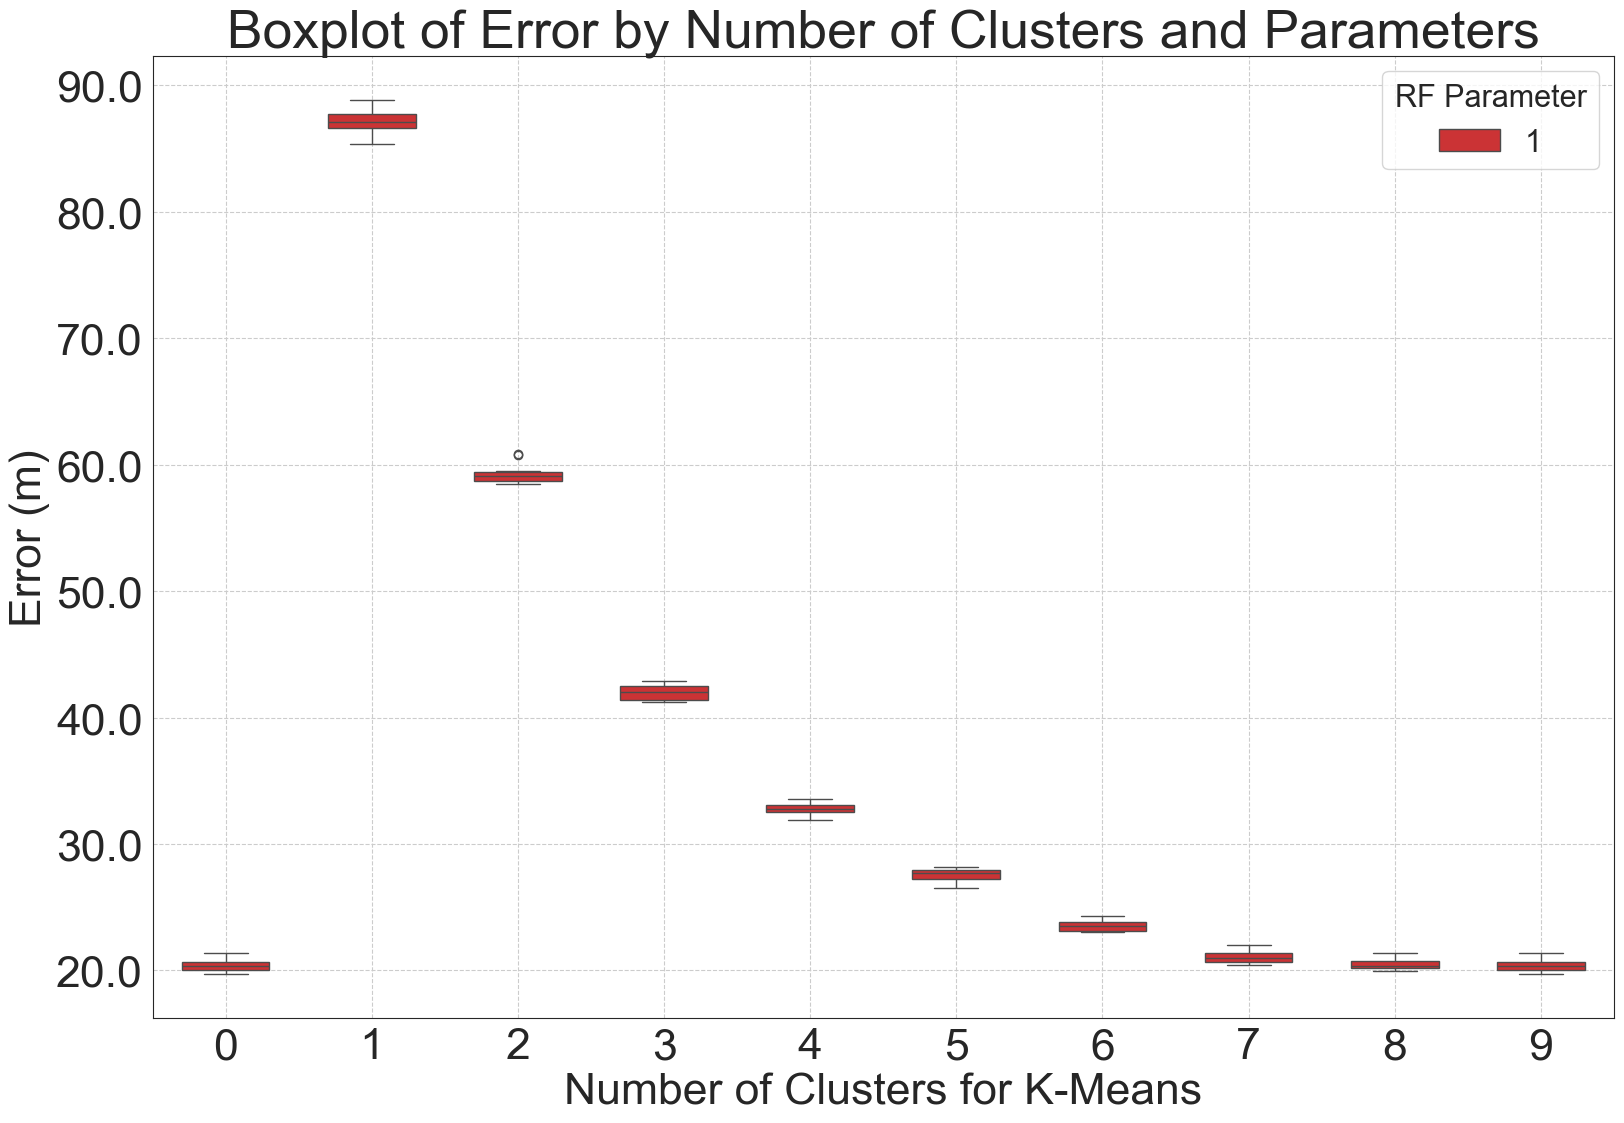

In [23]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 32})
# Set the style to white background
plt.figure(figsize=(17, 12))
sns.set_style("white")

sns.boxplot(x='n_best_beams', y='error', hue='operator', palette='Set1', data=data_df, width=0.6)

plt.xlim(-0.5, len(data_df['n_best_beams'].unique()) - 0.5)

# Add labels and title
plt.xlabel('Number of Clusters for K-Means')
plt.ylabel('Error (m)')
plt.title('Boxplot of Error by Number of Clusters and Parameters')

# Improve the legend
plt.legend(title='RF Parameter', fontsize='22', loc='upper right', title_fontsize=22, ncol=2)

# Remove grid or make it very subtle
plt.grid(linestyle='--')

from matplotlib.ticker import FormatStrFormatter

plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# Show the plot
plt.tight_layout()
plt.show()


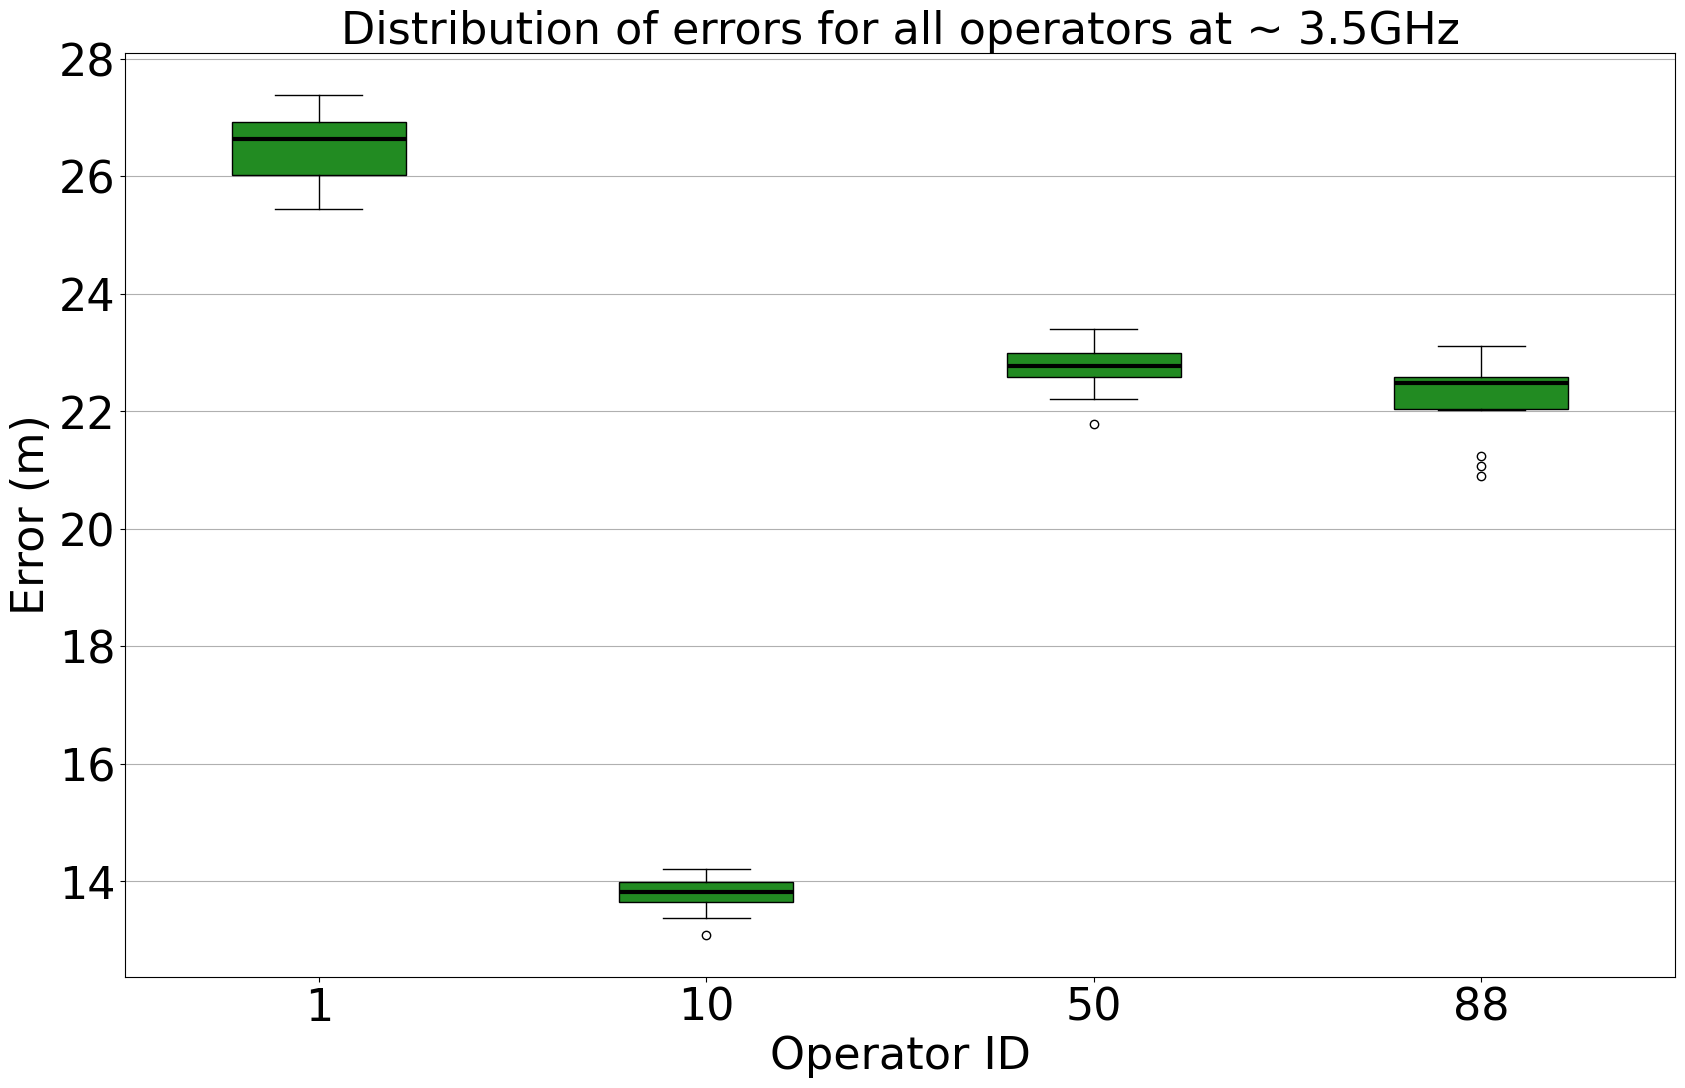

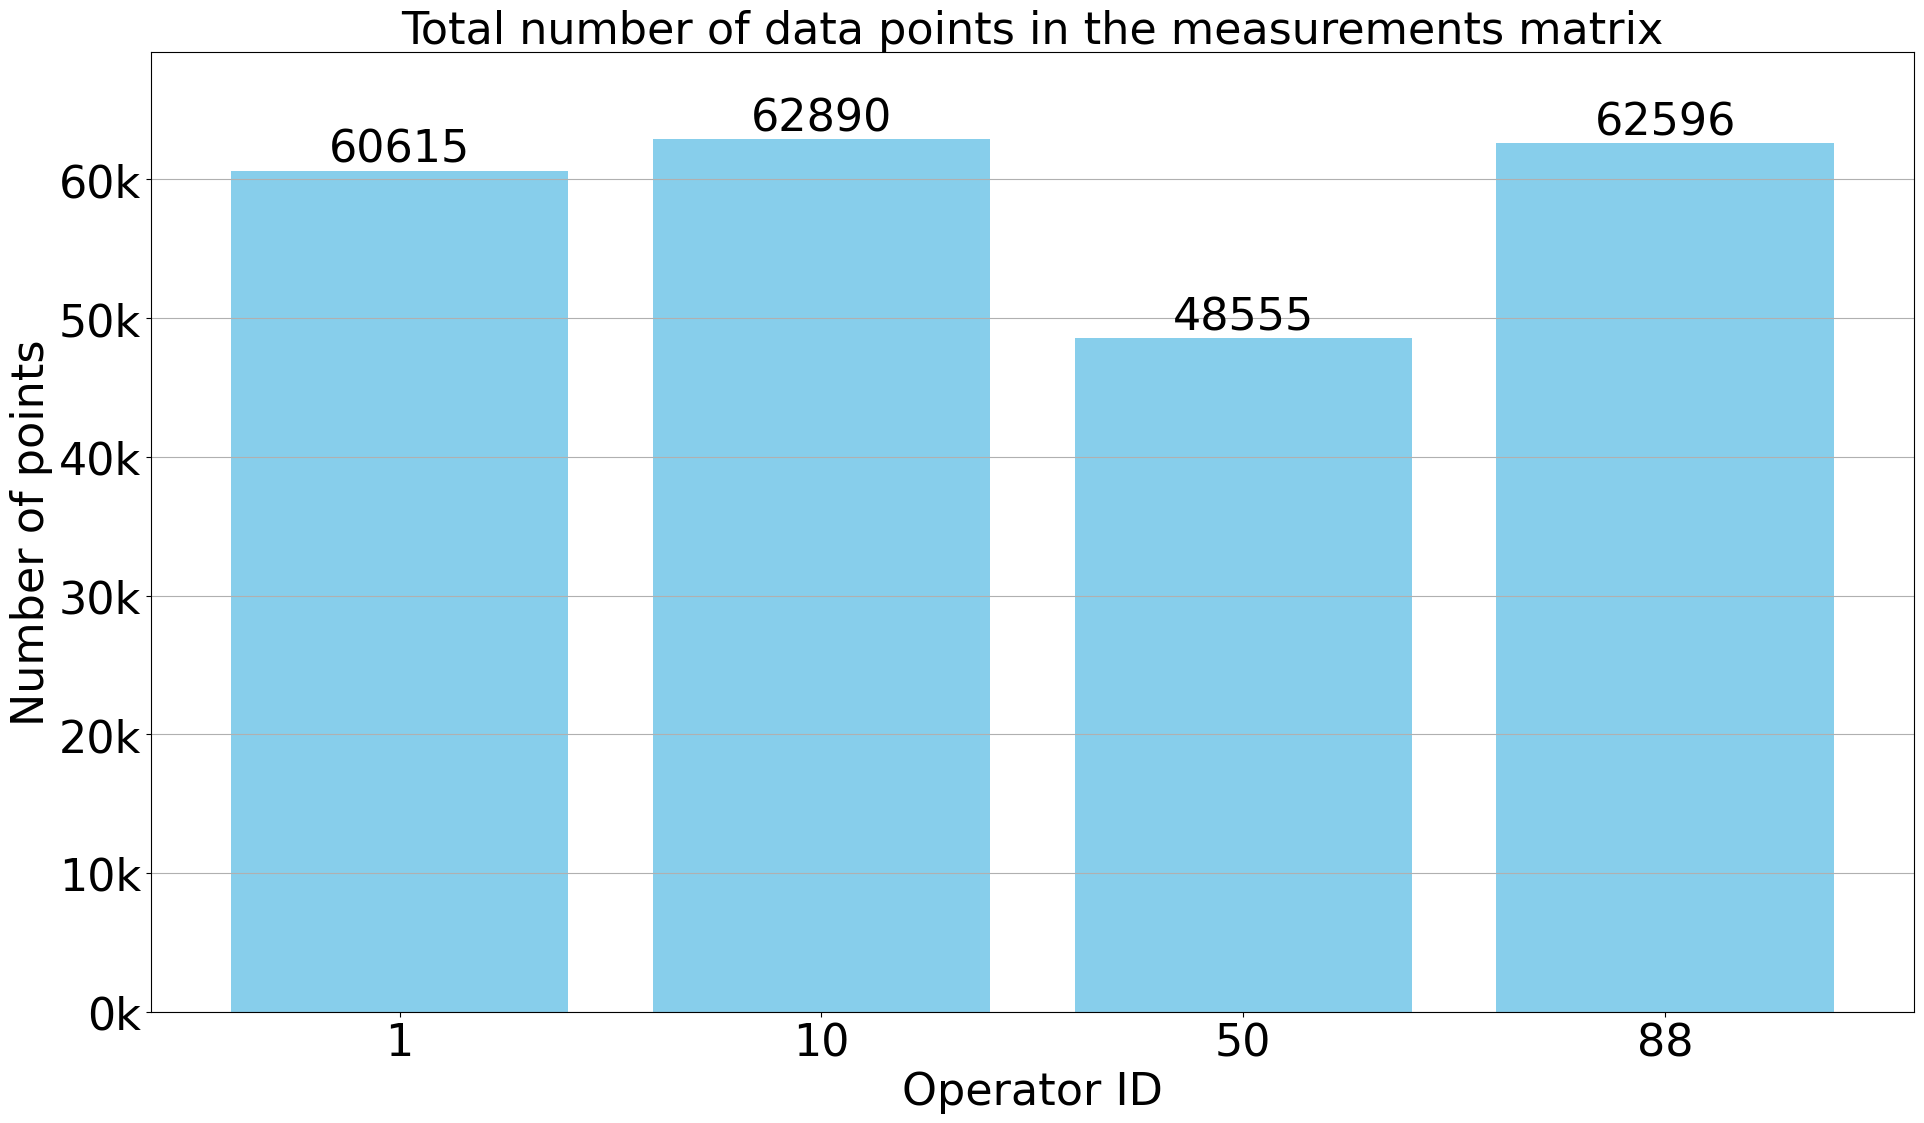

,1,10,50,88
0,12403,12609,12613,12616


In [17]:
from scripts.plotting import *

make_boxplot(
    df=errors_df[['1', '10', '50', '88']],
    x_label='Operator ID',
    y_label='Error (m)',
    title='Distribution of errors for all operators at ~ 3.5GHz',
)

make_barplot(
    df=entries_df,
    x_label='Operator ID',
    y_label='Number of points',
    title='Total number of data points in the measurements matrix',
    annotate=True,
    y_formatter=lambda x, pos: f"{x / 1000:.0f}k"

)
#
# make_barplot(
#     df=rps_df,
#     x_label='Operator ID',
#     y_label='Number of points',
#     title='Total number of valid reference points',
#     y_limit=(33100, 33600),
#     annotate=True,
#
# )

rps_df

        error   entries
1   41.208483   37051.0
10  12.711193  111287.0
50  21.144803  100235.0
88  22.849882   86445.0


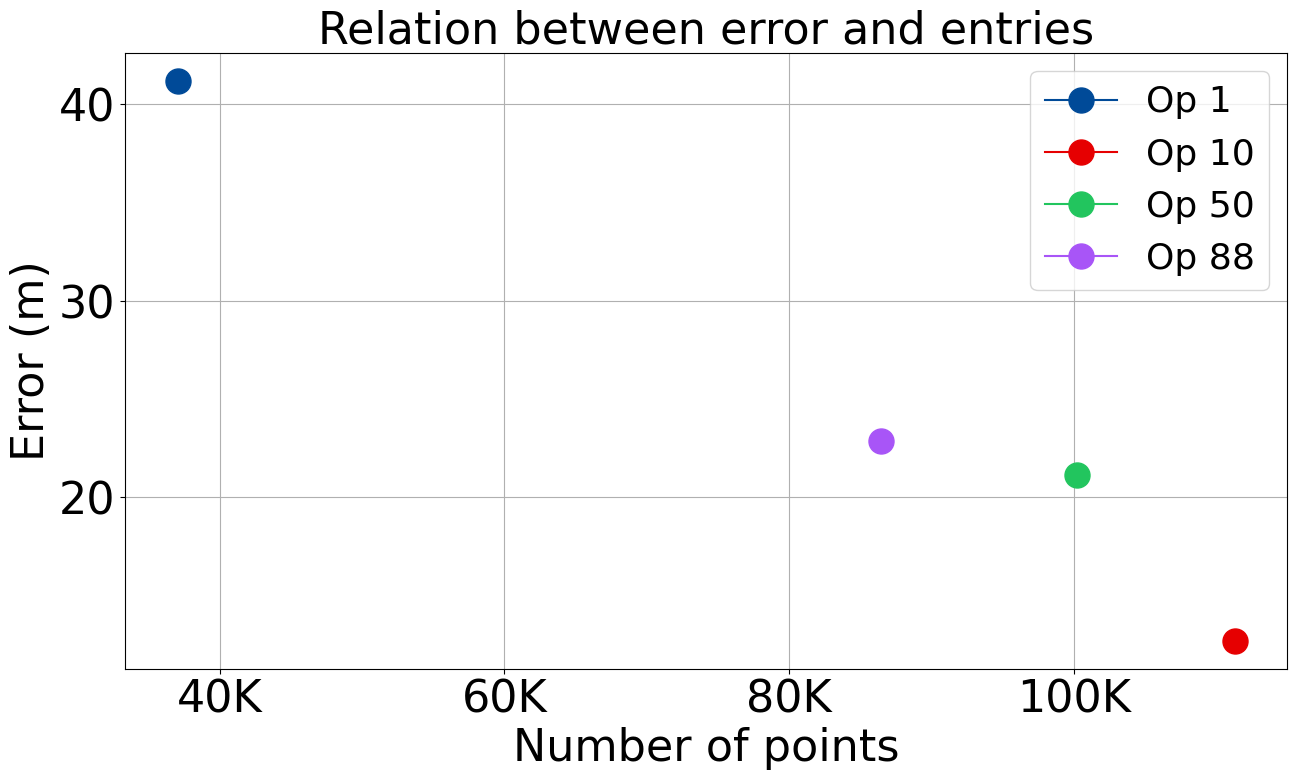

In [15]:


ratio_df = pd.DataFrame({
    'error': errors_df.mean(),
    'entries': entries_df.mean(),
})

from scripts.utils import get_config

color_map = get_config("color_map.json", "operatorId")

print(ratio_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i, row in ratio_df.iterrows():
    plt.plot(row['entries'], row['error'], label=f"Op {i}", marker='o', markersize=18, c=color_map[i])

plt.grid(True)
plt.legend()
plt.ylabel('Error (m)')
plt.title('Relation between error and entries')
plt.xlabel('Number of points')


def thousands_formatter(x, pos):
    return f"{x / 1000:.0f}k"


plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{(x / 1000):.0f}K"))

plt.show()